# Mackenzie River Outflow SSS and day of sea ice formation

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
from scipy.stats import t
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:45917")
client

<Client: 'tcp://127.0.0.1:45917' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 to since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

### Mask out SI for each day

In [11]:
# check shape of vars
print(theta_day.shape)
print(salt_day.shape)

(2543, 90, 1080, 1800)
(2543, 90, 1080, 1800)


### Isolate SSS, SST on September 15 and DOY for sea ice formation

In [23]:
# mask grid cells with >15% ice cover
SSS_icefree = salt_day.isel(k=0).where(ice_day<15)
SST_icefree = theta_day.isel(k=0).where(ice_day<15)

In [24]:
# select SSS on September 15 of each year
SSS_sep15 = SSS_icefree.sel(time=SSS_icefree['time'].dt.strftime('%m-%d') == '09-15')
SST_sep15 = SST_icefree.sel(time=SST_icefree['time'].dt.strftime('%m-%d') == '09-15')

Isolate DOY

In [25]:
ice_day = ice_day.assign_coords(DOY=ice_day['time'].dt.dayofyear)

In [26]:
# only select months later than september
# sic_fall = SI_beaufort.where(SI_beaufort['time.month'] >= 9, drop=True)
# sic_fall = SI_beaufort.where(SI_beaufort['time.month'] >= 10, drop=True)
sic_fall = ice_day.where(
    (ice_day['time.month'] > 9) | 
    ((ice_day['time.month'] == 9) & (ice_day['time.day'] > 15)), drop=True)

In [27]:
threshold = 15

In [84]:
# Group by year
results = []
for year, group in sic_fall.groupby('time.year'):
    # Subset the DOY variable for the current year
    doy_year = sic_fall.DOY.sel(time=group.time)
    
    # Create a mask for when the concentration exceeds the threshold
    threshold_mask = (group >= threshold)
    
    # Find the first time index where the mask is True for each grid cell
    first_time_index = threshold_mask.argmax(dim="time").compute()
    
    # Use the indices to find the corresponding DOY
    first_doy = doy_year.isel(time=first_time_index.astype(int))
    # first_doy = xr.where(all_false_mask, np.nan, first_doy)  # Set invalid cells to NaN

    # Add year as a dimension for later concatenation
    # first_doy = first_doy.expand_dims(year=[year])
    results.append(first_doy)

# Combine the results across years
threshold_dates = xr.concat(results, dim="year")

# mask out cells that never form sea ice (DOY=260)
threshold_dates = threshold_dates.where(threshold_dates>260,np.nan)

### Consolidate plots into one

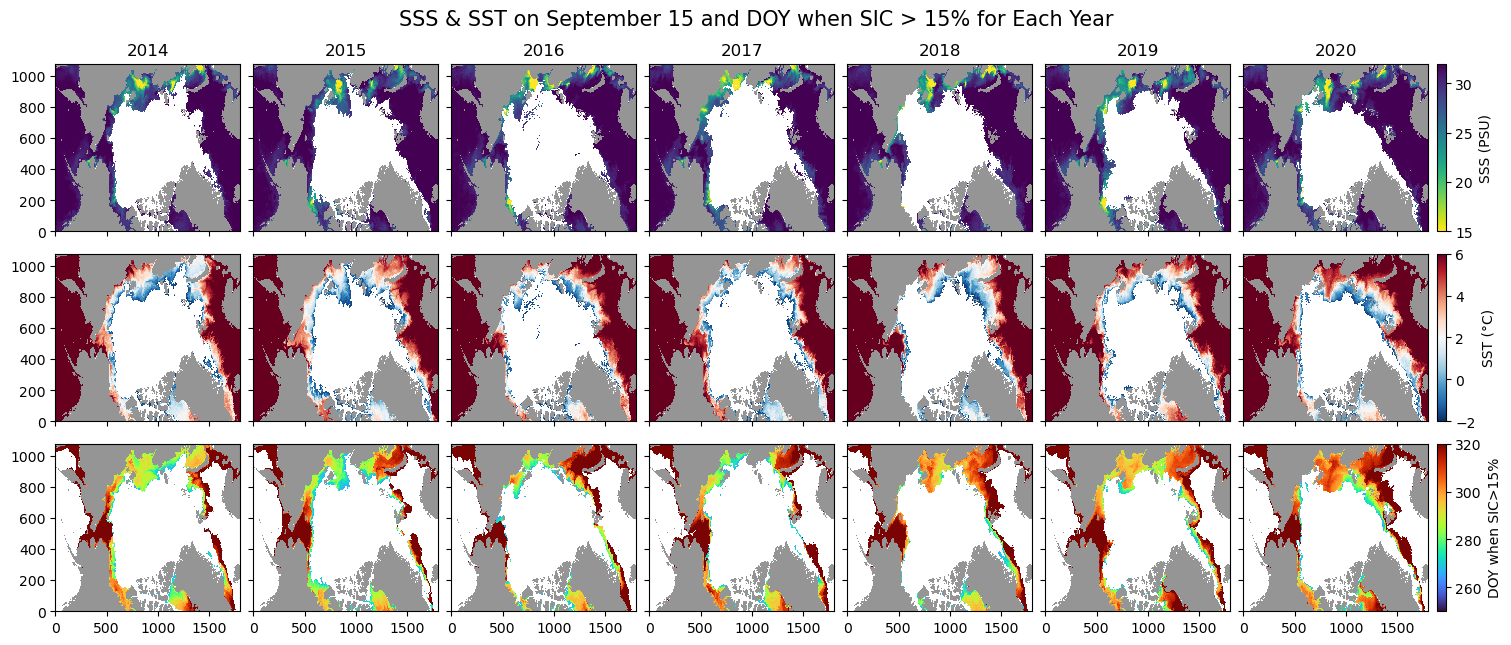

In [44]:
# Set up the figure and subplots (3 rows, 7 columns)
fig, axes = plt.subplots(3, 7, figsize=(15, 6), sharex=True, sharey=True, layout='constrained')
axes = axes.ravel()

# Define the colormap and range for each dataset
vmin_SSS = 15
vmax_SSS = 32
vmin_SST = -2
vmax_SST = 6
vmin_DOY = 260
vmax_DOY = 320

# Plot SSS on September 15 (Row 1)
for year in range(0, 7):
    ax = axes[year]
    SSS_sep15.isel(time=year).plot(ax=ax, cmap='viridis_r', vmin=vmin_SSS, vmax=vmax_SSS, add_colorbar=False)
    HH_grid_land.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(str(SSS_sep15.isel(time=year).time.dt.year.values))

# Add a colorbar for SSS (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=vmin_SSS, vmax=vmax_SSS)),
    ax=axes[6],  # Last subplot of the first row
    location='right'
)
cbar.ax.set_ylabel('SSS (PSU)')

# Plot SST on September 15 (Row 2)
for year in range(0, 7):
    ax = axes[year + 7]  # Offset by 7 for the second row
    SST_sep15.isel(time=year).plot(ax=ax, cmap='RdBu_r', vmin=vmin_SST, vmax=vmax_SST, add_colorbar=False)
    HH_grid_land.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_title(str(SST_sep15.isel(time=year).time.dt.year.values))
    ax.set_title("")

# Add a colorbar for SST (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin_SST, vmax=vmax_SST)),
    ax=axes[13],  # Last subplot of the second row
    location='right'
)
cbar.ax.set_ylabel('SST (°C)')

# Plot DOY when SIC > 15% (Row 3)
for year in range(0, 7):
    ax = axes[year + 14]  # Offset by 14 for the third row
    threshold_dates.isel(year=year).plot(ax=ax, cmap='turbo', vmin=vmin_DOY, vmax=vmax_DOY, add_colorbar=False)
    HH_grid_land.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_title(str(threshold_dates.isel(year=year, i=0, j=0).time.dt.year.values))
    ax.set_title("")

# Add a colorbar for DOY (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='turbo', norm=plt.Normalize(vmin=vmin_DOY, vmax=vmax_DOY)),
    ax=axes[20],  # Last subplot of the third row
    location='right'
)
cbar.ax.set_ylabel('DOY when SIC>15%')

# Add a title for the whole figure
plt.suptitle('SSS & SST on September 15 and DOY when SIC > 15% for Each Year', fontsize=15,y=1.05);

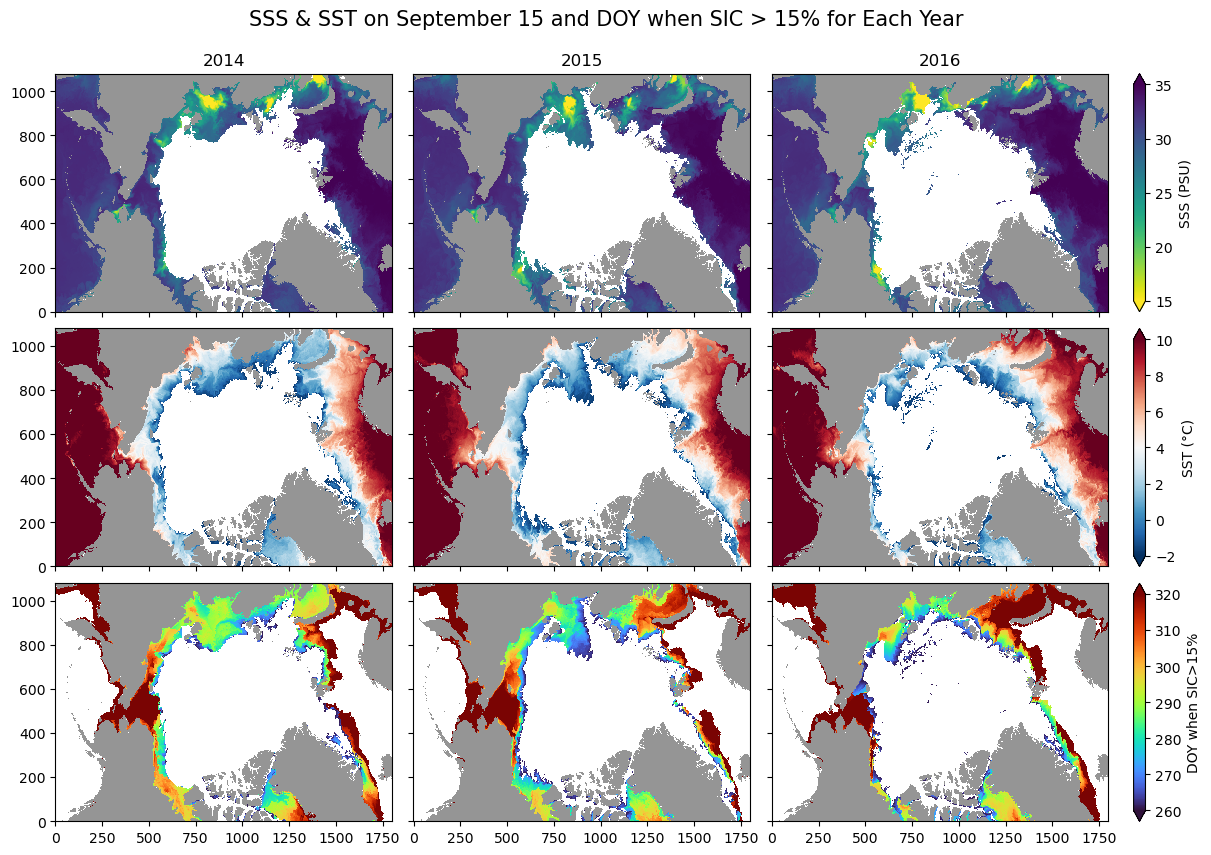

In [85]:
# Set up the figure and subplots (3 rows, 7 columns)
fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True, sharey=True, layout='constrained')
axes = axes.ravel()

# Define the colormap and range for each dataset
vmin_SSS = 15
vmax_SSS = 35
vmin_SST = -2
vmax_SST = 10
vmin_DOY = 260
vmax_DOY = 320

# Plot SSS on September 15 (Row 1)
for year in range(0, 3):
    ax = axes[year]
    SSS_sep15.isel(time=year).plot(ax=ax, cmap='viridis_r', vmin=vmin_SSS, vmax=vmax_SSS, add_colorbar=False)
    HH_grid_land.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(str(SSS_sep15.isel(time=year).time.dt.year.values))

# Add a colorbar for SSS (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=vmin_SSS, vmax=vmax_SSS)),
    ax=axes[2],  # Last subplot of the first row
    location='right', extend='both'
)
cbar.ax.set_ylabel('SSS (PSU)')

# Plot SST on September 15 (Row 2)
for year in range(0, 3):
    ax = axes[year + 3]  # Offset by 3 for the second row
    SST_sep15.isel(time=year).plot(ax=ax, cmap='RdBu_r', vmin=vmin_SST, vmax=vmax_SST, add_colorbar=False)
    HH_grid_land.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_title(str(SST_sep15.isel(time=year).time.dt.year.values))
    ax.set_title("")

# Add a colorbar for SST (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin_SST, vmax=vmax_SST)),
    ax=axes[5],  # Last subplot of the second row
    location='right', extend='both'
)
cbar.ax.set_ylabel('SST (°C)')

# Plot DOY when SIC > 15% (Row 3)
for year in range(0, 3):
    ax = axes[year + 6]  # Offset by 7 for the third row
    threshold_dates.isel(year=year).plot(ax=ax, cmap='turbo', vmin=vmin_DOY, vmax=vmax_DOY, add_colorbar=False)
    HH_grid_land.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_title(str(threshold_dates.isel(year=year, i=0, j=0).time.dt.year.values))
    ax.set_title("")

# Add a colorbar for DOY (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='turbo', norm=plt.Normalize(vmin=vmin_DOY, vmax=vmax_DOY)),
    ax=axes[8],  # Last subplot of the third row
    location='right', extend='both'
)
cbar.ax.set_ylabel('DOY when SIC>15%')

# Add a title for the whole figure
plt.suptitle('SSS & SST on September 15 and DOY when SIC > 15% for Each Year', fontsize=15,y=1.05);

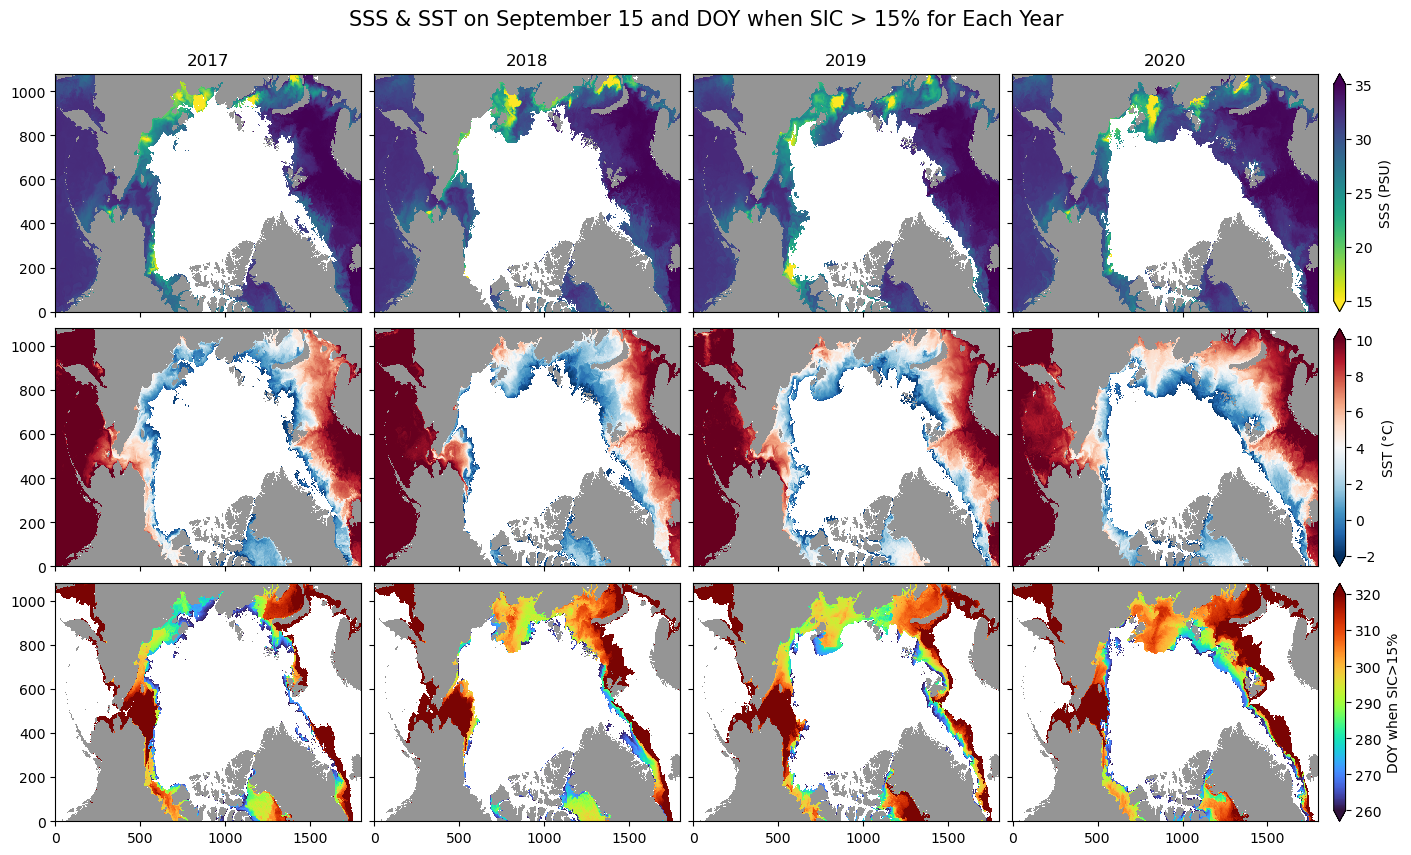

In [86]:
# Set up the figure and subplots (3 rows, 7 columns)
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True, sharey=True, layout='constrained')
axes = axes.ravel()

# Define the colormap and range for each dataset
vmin_SSS = 15
vmax_SSS = 35
vmin_SST = -2
vmax_SST = 10
vmin_DOY = 260
vmax_DOY = 320

# Plot SSS on September 15 (Row 1)
for year in range(3, 7):
    ax = axes[year-3]
    SSS_sep15.isel(time=year).plot(ax=ax, cmap='viridis_r', vmin=vmin_SSS, vmax=vmax_SSS, add_colorbar=False)
    HH_grid_land.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(str(SSS_sep15.isel(time=year).time.dt.year.values))

# Add a colorbar for SSS (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=vmin_SSS, vmax=vmax_SSS)),
    ax=axes[3],  # Last subplot of the first row
    location='right', extend='both'
)
cbar.ax.set_ylabel('SSS (PSU)')

# Plot SST on September 15 (Row 2)
for year in range(3, 7):
    ax = axes[year + 1]  # Offset by 3 for the second row
    SST_sep15.isel(time=year).plot(ax=ax, cmap='RdBu_r', vmin=vmin_SST, vmax=vmax_SST, add_colorbar=False)
    HH_grid_land.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_title(str(SST_sep15.isel(time=year).time.dt.year.values))
    ax.set_title("")

# Add a colorbar for SST (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin_SST, vmax=vmax_SST)),
    ax=axes[7],  # Last subplot of the second row
    location='right', extend='both'
)
cbar.ax.set_ylabel('SST (°C)')

# Plot DOY when SIC > 15% (Row 3)
for year in range(3, 7):
    ax = axes[year + 5]  # Offset by 7 for the third row
    threshold_dates.isel(year=year).plot(ax=ax, cmap='turbo', vmin=vmin_DOY, vmax=vmax_DOY, add_colorbar=False)
    HH_grid_land.plot(ax=ax, cmap='Greys', add_colorbar=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_title(str(threshold_dates.isel(year=year, i=0, j=0).time.dt.year.values))
    ax.set_title("")

# Add a colorbar for DOY (only on the last plot in the row)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='turbo', norm=plt.Normalize(vmin=vmin_DOY, vmax=vmax_DOY)),
    ax=axes[11],  # Last subplot of the third row
    location='right', extend='both'
)
cbar.ax.set_ylabel('DOY when SIC>15%')

# Add a title for the whole figure
plt.suptitle('SSS & SST on September 15 and DOY when SIC > 15% for Each Year', fontsize=15,y=1.05);